**Part 1b — Prompting, Tools & RAG** (2 of 4)
[Part 1a — API Fundamentals](https://github.com/Suvam-Ray/Claude_certified_architect/blob/main/part1a_fndmntl_api.ipynb) | **[Part 1b — Prompting, Tools & RAG](https://github.com/Suvam-Ray/Claude_certified_architect/blob/main/part1b_fndmntl_prompting_tools_rag.ipynb)** | [Part 2a — Advanced Features & MCP](https://github.com/Suvam-Ray/Claude_certified_architect/blob/main/part2a_advncd_features_mcp.ipynb) | [Part 2b — MCP Transport, Claude Code & Agents](https://github.com/Suvam-Ray/Claude_certified_architect/blob/main/part2b_advncd_mcp_claude_code_agents.ipynb)

## 40.1.2) Structured Output & Evaluation

### 40.1.2  a) Generating Structured Data - using hacks like i) Prefil and ii) Stop sequence
- This can be used to generate any structured data.<br><br>
- <font color="red"><b>**Prefil and Stop sequence :**</b></font> 
    - This is a very powerful trick used to generate structured data
    - After user message which has request to generate some structured data -- an assistant message is added - e.g. like `'''json` -- this will trick claude into assuming that it has already generated `'''json` ... so it will just continue and generate rest of json .... and then it will close the json with `'''` ... 
    - But then we will use a stop_sequence parameter -- which tells claude to stop generating the momemt it sees `'''`
    - So this way we trick claude to just generate the structured output only -- nothing else
    - **Very powerful**
    - prefill can be anything ... you can specify it.. 
    - **Note :** claude and insert comments .. or have 3 blocks instead of 1 ... to control all of that - the prefil assistant message can specify all of that -- see example 2 below 
    - `'''code` can also be used - insted of json or specific code -- which will keep it generic. <br><br>
- Note - the output json or whatever format .. it will have `\n` characters .. so we will have to still parse and strip them out before using


In [ ]:
# Updating chat function to add stop sequence
def chat(messages, system=None, temperature=1.0, stop_sequences=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature
    }
    
    if system:
        params["system"] = system
    
    if stop_sequences:
        params["stop_sequences"] = stop_sequences
    
    message = client.messages.create(**params)
    return message.content[0].text

In [ ]:
messages = []
add_user_message(messages,"Generate a very short event bridge rule as a json")

# Adding the assistant message starting with json to trick claude into generating just the json
add_assistant_message(messages,"```json")

# Adding stop sequence to force claude to stop generating once json is complete
json_output = chat(messages, stop_sequences=["```"])
json_output

'\n{\n  "Name": "UserSignupRule",\n  "EventPattern": {\n    "source": ["myapp.users"],\n    "detail-type": ["User Signup"]\n  },\n  "State": "ENABLED",\n  "Targets": [\n    {\n      "Id": "1",\n      "Arn": "arn:aws:lambda:us-east-1:123456789012:function:ProcessSignup"\n    }\n  ]\n}\n'

In [ ]:
# Parsing the json output
import json
json.loads(json_output.strip())

{'Name': 'UserSignupRule',
 'EventPattern': {'source': ['myapp.users'], 'detail-type': ['User Signup']},
 'State': 'ENABLED',
 'Targets': [{'Id': '1',
   'Arn': 'arn:aws:lambda:us-east-1:123456789012:function:ProcessSignup'}]}

In [ ]:
# Example 2 -- Without stop sequence and prefilling

messages = []
add_user_message(messages,"Generate three sample AWS CLI commands. Each should be very short.")
response = chat(messages)

from IPython.display import Markdown
Markdown(response)

Here are three short AWS CLI commands:

1. **List S3 buckets:**
   ```
   aws s3 ls
   ```

2. **Describe EC2 instances:**
   ```
   aws ec2 describe-instances
   ```

3. **List IAM users:**
   ```
   aws iam list-users
   ```

In [ ]:
# Example 2 -- With stop sequence and prefilling

messages = []
add_user_message(messages,"Generate three sample AWS CLI commands. Each should be very short.")

add_assistant_message(messages,"Here are all the 3 commands in a single block without any comments```bash")

response = chat(messages, stop_sequences=["```"])

response.strip()

'aws s3 ls\naws ec2 describe-instances\naws iam list-users'

### 40.1.2  b) Using Eval to Refine Prompt
- Step 1 : create an eval dataset of 100 or 1000 questions
    - Claude Haiku or any fast model can be used for this -- example below<br><br>
- Step 2 : pass these questions to the LLM and get the response<br><br>
- Step 3 : The response are fed to a grader. There are many types of graders .... 
    - a) Deterministic grader - like a python script
    - b) LLM as a Judge - Having a more capable LLM doing the grading of the response
    - c) Human grader - doing it manually<br><br>
- Step 4 : Update prompt - and run eval again 


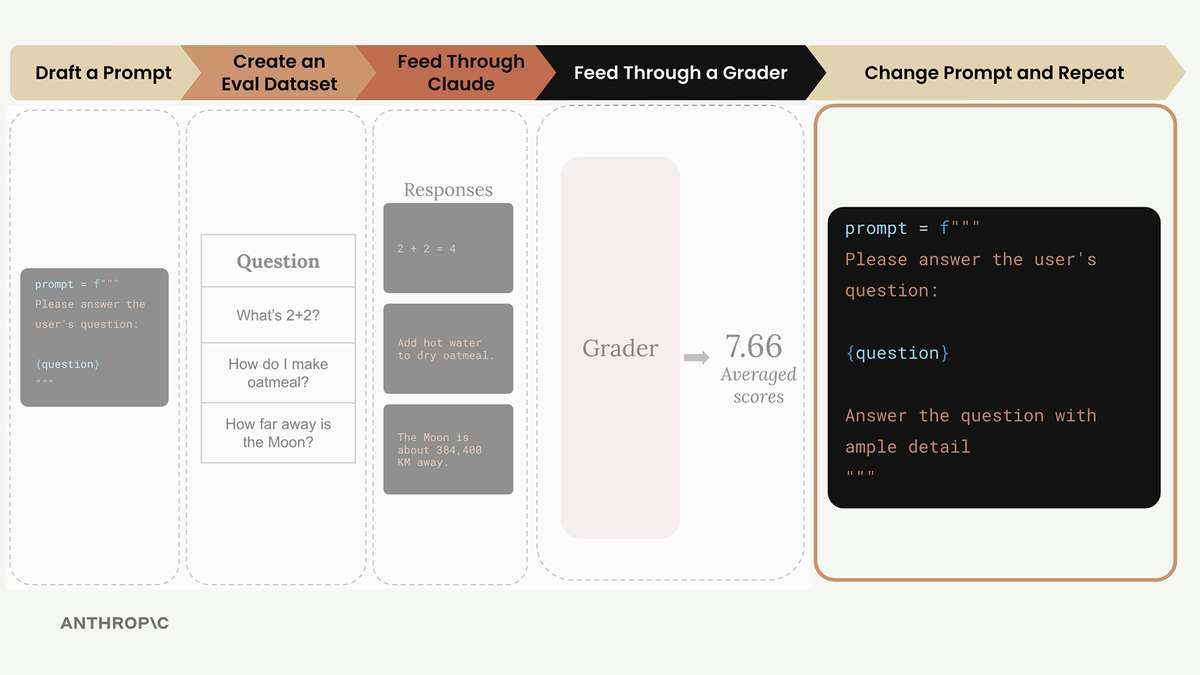

In [ ]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/prompt_eval.png', embed=True))

### 40.1.2  c) Eval Task
- Our prompt needs to assist users in writing three specific types of output for AWS use cases:
    - Python code
    - JSON configuration files
    - Regular expressions<br><br>
- The key requirement is that when a user requests help with a task, we return clean output in one of these formats without any extra explanations, headers, or footers.


### 40.1.2  d) Step 1: Using Haiku to Generate Eval Dataset


In [ ]:
# Updating chat function to use haiku
def chat(messages, system=None, temperature=1.0, stop_sequences=None):
    params = {
        "model": "claude-haiku-4-5-20251001",
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature
    }
    
    if system:
        params["system"] = system
    
    if stop_sequences:
        params["stop_sequences"] = stop_sequences
    
    message = client.messages.create(**params)
    return message.content[0].text

In [ ]:
import json


def generate_dataset():
    prompt = """
Generate a evaluation dataset for a prompt evaluation. The dataset will be used to evaluate prompts
that generate Python, JSON, or Regex specifically for AWS-related tasks. Generate an array of JSON objects,
each representing task that requires Python, JSON, or a Regex to complete.

Example output:
```json
[
    {
        "task": "Description of task",
    },
    ...additional
]
```

* Focus on tasks that can be solved by writing a single Python function, a single JSON object, or a regular expression.
* Focus on tasks that do not require writing much code

Please generate 3 objects.
"""
    messages = []
    add_user_message(messages,prompt)
    add_assistant_message(messages,"Here are the 3 tasks in a single json block without any comments ```json")
    text = chat(messages, stop_sequences = ["```"])
    return json.loads(text)

In [ ]:
dataset = generate_dataset()
print(dataset)

# Saving the dataset in a json file
with open("Input_and_Output/eval_dataset.json", "w") as f:
    json.dump(dataset, f, indent = 2)

[{'task': "Write a Python function that parses an AWS S3 object key and extracts the bucket name, folder path, and file name from a full S3 URI like 's3://my-bucket/folder/subfolder/file.txt'"}, {'task': 'Create a JSON object that represents an AWS Lambda function configuration with environment variables for database connection (host, port, username) and IAM role ARN'}, {'task': "Write a regular expression that matches valid AWS IAM role ARNs in the format 'arn:aws:iam::123456789012:role/RoleName' and captures the account ID and role name separately"}]


### 40.1.2  e) Step 2 & 3: Passing Test Cases and Grading Responses
- run_eval --> loads the test case dataset ... and loops on the case 1 by 1 .. and calls run_test_case on the dataset
- run_test_case --> takes a test case from run_eval .. then calls run_prompt on that case to get response from LLM .. then runs a grading algorithm ( TODO for now - will be updated later ) .. and returns the test_case, response and score to the run_eval.


In [ ]:
def run_prompt(test_case):
    """Merges the prompt and test case input, then returns the result"""
    prompt = f"""
Please solve the following task:

{test_case["task"]}
"""
    
    messages = []
    add_user_message(messages, prompt)
    output = chat(messages)
    return output

In [ ]:
def run_test_case(test_case):
    """Calls run_prompt, then grades the result"""
    output = run_prompt(test_case)
    
    # TODO - Grading
    score = 10
    
    return {
        "output": output,
        "test_case": test_case,
        "score": score
    }

In [ ]:
def run_eval(dataset):
    """Loads the dataset and calls run_test_case with each case"""
    results = []
    
    for test_case in dataset:
        result = run_test_case(test_case)
        results.append(result)
    
    return results

In [ ]:
with open("Input_and_Output/eval_dataset.json", "r") as f:
    dataset = json.load(f)

results = run_eval(dataset)
print(json.dumps(results, indent = 2))

[
  {
    "output": "# AWS S3 URI Parser\n\nHere's a comprehensive solution with multiple approaches:\n\n## Solution 1: Simple and Direct (Recommended)\n\n```python\ndef parse_s3_uri(s3_uri: str) -> dict:\n    \"\"\"\n    Parse an AWS S3 URI and extract bucket name, folder path, and file name.\n    \n    Args:\n        s3_uri: Full S3 URI (e.g., 's3://my-bucket/folder/subfolder/file.txt')\n    \n    Returns:\n        Dictionary containing:\n        - bucket: The S3 bucket name\n        - folder_path: The folder path (without trailing slash)\n        - file_name: The file name (including extension)\n        - full_key: The complete object key (folder_path + file_name)\n    \n    Raises:\n        ValueError: If the URI format is invalid\n    \"\"\"\n    # Validate and clean the URI\n    if not s3_uri or not isinstance(s3_uri, str):\n        raise ValueError(\"S3 URI must be a non-empty string\")\n    \n    s3_uri = s3_uri.strip()\n    \n    # Check for s3:// prefix\n    if not s3_uri.sta

### 40.1.2  f) Step 3: Implementing Grader
- There are 3 types of graders 
    - Code : Programmatically evaluate result
    - Model : Ask an LLM to evaluate the result
    - Human : Ask Human to assign a score<br><br>
- We will implement the following for the use case


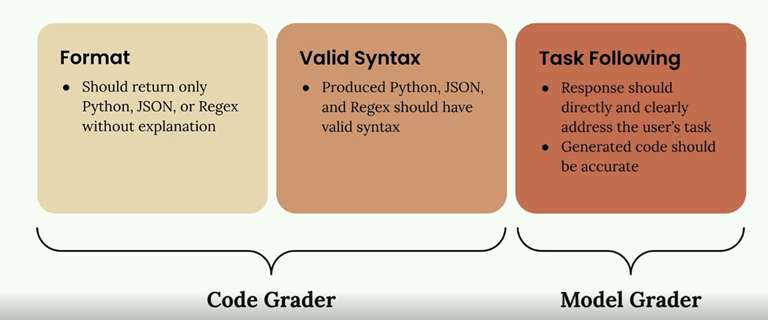

In [ ]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/grader.png', embed=True))

### 40.1.2  g) Step 3: Implementing Model-based Grader
- Dont just ask for score by the model grader ... It will just give average score to every test case
- Instead ask the model grader to give the strength, weakness, reasoning and score ... this forces model grader to think and assign score properly 


In [ ]:
# replacing todo in this with another function call for grader
def run_test_case(test_case):
    output = run_prompt(test_case)
    
    # Grade the output
    model_grade = grade_by_model(test_case, output)
    score = model_grade["score"]
    reasoning = model_grade["reasoning"]
    
    return {
        "output": output, 
        "test_case": test_case, 
        "score": score,
        "reasoning": reasoning
    }

In [ ]:
def grade_by_model(test_case, output):
    # Create evaluation prompt
    eval_prompt = f"""
You are an expert AWS code reviewer. Your task is to evaluate the following AI-generated solution.

Original Task:
<task>
{test_case["task"]}
</task>

Solution to Evaluate:
<solution>
{output}
</solution>

Output Format
Provide your evaluation as a structured JSON object with the following fields, in this specific order:
- "strengths": An array of 1-3 key strengths
- "weaknesses": An array of 1-3 key areas for improvement
- "reasoning": A concise explanation of your overall assessment
- "score": A number between 1-10

Respond with JSON. Keep your response concise and direct.
Example response shape:
{{
    "strengths": string[],
    "weaknesses": string[],
    "reasoning": string,
    "score": number
}}
    """
    
    messages = []
    add_user_message(messages, eval_prompt)
    add_assistant_message(messages, """Here is a single json block with the information """
                          """requested - without any comments ```json""")
    
    eval_text = chat(messages, stop_sequences=["```"])
    return json.loads(eval_text)

In [ ]:
from statistics import mean

def run_eval(dataset):
    results = []
    
    for test_case in dataset:
        result = run_test_case(test_case)
        results.append(result)
    
    average_score = mean([result["score"] for result in results])
    print(f"Average score: {average_score}")
    
    return results

In [ ]:
with open("Input_and_Output/eval_dataset.json", "r") as f:
    dataset = json.load(f)

results = run_eval(dataset)
print(json.dumps(results, indent = 2))

Average score: 7.333333333333333
[
  {
    "output": "# AWS S3 URI Parser\n\nHere's a comprehensive solution with multiple approaches:\n\n## Solution 1: Simple and Clean (Recommended)\n\n```python\nfrom urllib.parse import urlparse\nfrom typing import Tuple\n\ndef parse_s3_uri(s3_uri: str) -> Tuple[str, str, str]:\n    \"\"\"\n    Parse an S3 URI and extract bucket name, folder path, and file name.\n    \n    Args:\n        s3_uri: Full S3 URI (e.g., 's3://my-bucket/folder/subfolder/file.txt')\n    \n    Returns:\n        Tuple of (bucket_name, folder_path, file_name)\n    \n    Raises:\n        ValueError: If the URI is not a valid S3 URI\n    \"\"\"\n    parsed = urlparse(s3_uri)\n    \n    # Validate S3 URI\n    if parsed.scheme != 's3':\n        raise ValueError(f\"Invalid S3 URI scheme: {parsed.scheme}. Expected 's3'\")\n    \n    bucket_name = parsed.netloc\n    if not bucket_name:\n        raise ValueError(\"Bucket name is missing from S3 URI\")\n    \n    # Remove leading slash

### 40.1.2  h) Step 3: Implementing Code-based Grader
- We will implement parsing functions for json, python, regex .. and if parsing is successful - grade is 10 .. else grade is 0
- We will have 3 functions 1 each for json, python, regex ... so we will update the dataset generation function to also have a key which indicates the language ... and this key will be used by the grader to call the right function. 


In [ ]:
# Function to generate a new dataset
import json


def generate_dataset():
    prompt = """
Generate a evaluation dataset for a prompt evaluation. The dataset will be used to evaluate prompts
that generate Python, JSON, or Regex specifically for AWS-related tasks. Generate an array of JSON objects,
each representing task that requires Python, JSON, or a Regex to complete.

Example output:
```json
[
    {
        "task": "Description of task",
        "format": "json" or "python" or "regex"
    },
    ...additional
]
```

* Focus on tasks that can be solved by writing a single Python function, a single JSON object, or a regular expression.
* Focus on tasks that do not require writing much code

Please generate 3 objects.
"""

    messages = []
    add_user_message(messages, prompt)
    add_assistant_message(messages,"""Here are the 3 tasks along with format for each """
                          """in a single json block without any comments ```json""")
    text = chat(messages, stop_sequences=["```"])
    return json.loads(text)

In [ ]:
dataset = generate_dataset()
print(dataset)

# Saving the dataset in a json file
with open("Input_and_Output/eval_dataset.json", "w") as f:
    json.dump(dataset, f, indent = 2)

[{'task': 'Parse an AWS CloudWatch log entry and extract the timestamp, log level, and message using a regular expression', 'format': 'regex'}, {'task': 'Create a JSON configuration file for an AWS Lambda function that specifies environment variables, timeout, and memory allocation', 'format': 'json'}, {'task': 'Write a Python function that takes an AWS S3 bucket name and file key as input and returns whether the object exists', 'format': 'python'}]


In [ ]:
# Functions to validate the output structure
import re
import ast


def validate_json(text):
    try:
        json.loads(text.strip())
        return 10
    except json.JSONDecodeError:
        return 0


def validate_python(text):
    try:
        ast.parse(text.strip())
        return 10
    except SyntaxError:
        return 0


def validate_regex(text):
    try:
        re.compile(text.strip())
        return 10
    except re.error:
        return 0


def grade_syntax(response, test_case):
    format = test_case["format"]
    if format == "json":
        return validate_json(response)
    elif format == "python":
        return validate_python(response)
    else:
        return validate_regex(response)


In [ ]:
# Updating the prompt in run_prompt to ensure that it only returns code without comments 
# Also adding prefill assistant message with ```code -- for generic code implementation
def run_prompt(test_case):
    prompt = f"""
Please solve the following task:

{test_case["task"]}

* Respond only with Python, JSON, or a plain Regex
* Do not add any comments or commentary or explanation
"""

    messages = []
    add_user_message(messages, prompt)
    add_assistant_message(messages, """Here is the code in a single code block without """
                          """comments or explanation ```code""")
    output = chat(messages, stop_sequences=["```"])
    return output

In [ ]:
# Updating run_test_case to add the syntax grader
def run_test_case(test_case):
    """Calls run_prompt, then grades the result"""
    output = run_prompt(test_case)

    model_grade = grade_by_model(test_case, output)
    model_score = model_grade["score"]
    reasoning = model_grade["reasoning"]

    syntax_score = grade_syntax(output, test_case)

    score = (model_score + syntax_score) / 2

    return {
        "output": output,
        "test_case": test_case,
        "score": score,
        "reasoning": reasoning,
    }

In [ ]:
# Running the final evaluation again 
with open("Input_and_Output/eval_dataset.json", "r") as f:
    dataset = json.load(f)

results = run_eval(dataset)
print(json.dumps(results, indent = 2))

Average score: 5.5
[
  {
    "output": "\nimport re\nimport json\n\n# Regular expression pattern for parsing AWS CloudWatch log entry\npattern = r'(\\d{4}-\\d{2}-\\d{2}T\\d{2}:\\d{2}:\\d{2}\\.\\d{3}Z)\\s+(\\w+)\\s+(.*)'\n\n# Example AWS CloudWatch log entry\nlog_entry = '2024-01-15T10:30:45.123Z ERROR Failed to connect to database'\n\n# Parse the log entry\nmatch = re.match(pattern, log_entry)\n\nif match:\n    timestamp, log_level, message = match.groups()\n    result = {\n        \"timestamp\": timestamp,\n        \"log_level\": log_level,\n        \"message\": message\n    }\n    print(json.dumps(result, indent=2))\n",
    "test_case": {
      "task": "Parse an AWS CloudWatch log entry and extract the timestamp, log level, and message using a regular expression",
      "format": "regex"
    },
    "score": 8.0,
    "reasoning": "The solution provides a working baseline for parsing standard CloudWatch logs, but lacks robustness for production use. The regex pattern is reasonable but 

### 40.1.2  i) Adding Solution Criteria for Better Grading


In [ ]:
# Updated generate_dataset to have solution criteria also
import json


def generate_dataset():
    prompt = """
Generate a evaluation dataset for a prompt evaluation. The dataset will be used to evaluate prompts
that generate Python, JSON, or Regex specifically for AWS-related tasks. Generate an array of JSON objects,
each representing task that requires Python, JSON, or a Regex to complete.

Example output:
```json
[
    {
        "task": "Description of task",
        "format": "json" or "python" or "regex",
        "solution_criteria": "Key criteria for evaluating the solution"
    },
    ...additional
]
```

* Focus on tasks that can be solved by writing a single Python function, a single JSON object, or a regular expression.
* Focus on tasks that do not require writing much code

Please generate 3 objects.
"""

    messages = []
    add_user_message(messages, prompt)
    add_assistant_message(messages,"""Here are the 3 tasks along with format for each """
                          """in a single json block without any comments ```json""")
    text = chat(messages, stop_sequences=["```"])
    return json.loads(text)

In [ ]:
dataset = generate_dataset()
print(dataset)

# Saving the dataset in a json file
with open("Input_and_Output/eval_dataset.json", "w") as f:
    json.dump(dataset, f, indent = 2)

[{'task': "Extract all IAM role ARNs from an AWS CloudTrail log file. The ARNs follow the pattern 'arn:aws:iam::ACCOUNT_ID:role/ROLE_NAME'", 'format': 'regex', 'solution_criteria': 'The regex must accurately match all valid IAM role ARNs and capture the account ID and role name components'}, {'task': 'Create a JSON configuration template for an AWS Lambda function that specifies runtime, memory, timeout, and environment variables for a Node.js application', 'format': 'json', 'solution_criteria': 'The JSON must be valid, include required Lambda configuration keys, and demonstrate proper structure for environment variables'}, {'task': 'Write a Python function that takes an AWS S3 bucket name and prefix as arguments and returns a dictionary containing the total size of all objects matching that prefix', 'format': 'python', 'solution_criteria': 'The function must use boto3, handle pagination for large result sets, calculate total size in bytes, and handle edge cases like empty prefixes'}]


In [ ]:
# Updating model grader to consider the solution criteria also
def grade_by_model(test_case, output):
    eval_prompt = f"""
You are an expert AWS code reviewer. Your task is to evaluate the following AI-generated solution.

Original Task:
<task>
{test_case["task"]}
</task>

Solution to Evaluate:
<solution>
{output}
</solution>

Criteria you should use to evaluate the solution:
<criteria>
{test_case["solution_criteria"]}
</criteria>

Output Format
Provide your evaluation as a structured JSON object with the following fields, in this specific order:
- "strengths": An array of 1-3 key strengths
- "weaknesses": An array of 1-3 key areas for improvement
- "reasoning": A concise explanation of your overall assessment
- "score": A number between 1-10

Respond with JSON. Keep your response concise and direct.
Example response shape:
{{
    "strengths": string[],
    "weaknesses": string[],
    "reasoning": string,
    "score": number
}}
    """

    messages = []
    add_user_message(messages, eval_prompt)
    add_assistant_message(messages, """Here is a single json block with the information """
                          """requested - without any comments ```json""")
    eval_text = chat(messages, stop_sequences=["```"])
    return json.loads(eval_text)

In [ ]:
# Running the final evaluation again 
with open("Input_and_Output/eval_dataset.json", "r") as f:
    dataset = json.load(f)

results = run_eval(dataset)
print(json.dumps(results, indent = 2))

Average score: 5.5
[
  {
    "output": "\nimport re\nimport json\nimport sys\n\ndef extract_iam_role_arns(log_content):\n    pattern = r'arn:aws:iam::\\d{12}:role/[a-zA-Z0-9\\-_./]+'\n    matches = re.findall(pattern, log_content)\n    return list(set(matches))\n\nif __name__ == \"__main__\":\n    if len(sys.argv) > 1:\n        with open(sys.argv[1], 'r') as f:\n            log_content = f.read()\n        arns = extract_iam_role_arns(log_content)\n        print(json.dumps(arns, indent=2))\n    else:\n        log_content = sys.stdin.read()\n        arns = extract_iam_role_arns(log_content)\n        print(json.dumps(arns, indent=2))\n",
    "test_case": {
      "task": "Extract all IAM role ARNs from an AWS CloudTrail log file. The ARNs follow the pattern 'arn:aws:iam::ACCOUNT_ID:role/ROLE_NAME'",
      "format": "regex",
      "solution_criteria": "The regex must accurately match all valid IAM role ARNs and capture the account ID and role name components"
    },
    "score": 8.0,
    "r

## 40.1.3) Prompt Engineering

### 40.1.3  a) Prompt Engineering
- The file utils/eval_functions.py has final professional version of all the functions written so far. 
- We will import from it and use for prompt engineering
- In this prompt engineering section - we will use a prompt - then run eval - then update the prompt using prompt engineering techniques
- The eval suite from the utils file also generates a html file report of the evaluation - which is very professional
- This util also has parallelism implemented .. so the api will be called parallely ... max_concurrent_tasks is used to control it ... how to use it is covered below. 


In [ ]:
# Importing the util
from utils.eval_functions import (
    add_user_message, add_assistant_message, chat,
    generate_prompt_evaluation_report, PromptEvaluator )

In [ ]:
# Load the api key from the .env file
from dotenv import load_dotenv
load_dotenv()

# Create a client to Anthropic
from anthropic import Anthropic

client = Anthropic()
model = "claude-sonnet-4-0"

In [ ]:
# Create an instance of PromptEvaluator
# Increase `max_concurrent_tasks` for greater concurrency, but beware of rate limit errors!
# Dont go for max_concurrent_tasks beyond 3
evaluator = PromptEvaluator(max_concurrent_tasks=3)

In [ ]:
dataset = evaluator.generate_dataset(
    # Describe the purpose or goal of the prompt you're trying to test
    task_description="",
    # Describe the different inputs that your prompt requires
    prompt_inputs_spec={
        "height": "Athlete's height in cm",
        "weight":"Athlete's height in kg",
        "goal":"Goal of the athelete",
        "restrictions":"Dietary restriction of the athelete"
    },
    # Where to write the generated dataset
    output_file="Input_and_Output/prompt_engineering_dataset.json",
    # Number of test cases to generate (recommend keeping this low if you're getting rate limit errors)
    num_cases=3,
)

print(dataset)

Generated 1/3 test cases
Generated 2/3 test cases
Generated 3/3 test cases
[{'prompt_inputs': {'height': '', 'weight': '', 'goal': '', 'restrictions': ''}, 'solution_criteria': ['System handles empty inputs gracefully without crashing', 'System either requests required information or provides a default response', 'System clearly communicates what information is needed to proceed'], 'task_description': '', 'scenario': 'Testing with empty or minimal input to verify error handling and default behavior'}, {'prompt_inputs': {'height': '178 cm', 'weight': '82 kg', 'goal': 'Build muscle mass while improving cardiovascular endurance', 'restrictions': 'Vegetarian, lactose intolerant'}, 'solution_criteria': ['Provides a nutrition plan that accommodates vegetarian diet and avoids dairy products', 'Includes specific macronutrient targets or food recommendations supporting both muscle building and cardiovascular goals', 'Offers practical, actionable guidance suitable for implementation within 1-2 w

In [ ]:
# Define and run the prompt you want to evaluate, returning the raw model output
# This function is executed once for each test case
def run_prompt(prompt_inputs):
    prompt = f"""
    What should this person eat ? 
    - Height: {prompt_inputs["height"]}
    - Weight: {prompt_inputs["weight"]}
    - Goal: {prompt_inputs["goal"]}
    - Dietary restrictions: {prompt_inputs["restrictions"]}
    """

    messages = []
    add_user_message(messages, prompt)
    return chat(messages)

In [ ]:
# The extra criteria .. is an additional criteria on top of criteria generated by the generate dataset
results = evaluator.run_evaluation(
    run_prompt_function=run_prompt, dataset_file="Input_and_Output/prompt_engineering_dataset.json",
    extra_criteria="""
    The output should include:
        - Daily caloric total
        - Macronutrient breakdown
        - Meals with exact foods, portions and timings
    """
)

Graded 1/3 test cases
Graded 2/3 test cases
Graded 3/3 test cases
Average score: 3


- Running the above generates "output.HTML" - with **a very nice looking professional report**
- Next we will change prompt in run_prompt ... using prompt engineering practices .. and re-evaluate to get improved scores. 

### 40.1.3  b) Be Clear and Direct
- Give clear instruction on what is needed in the prompt
- Have an action verb like .. generate or create this .. 


In [ ]:
# Define and run the prompt you want to evaluate, returning the raw model output
# This function is executed once for each test case
def run_prompt(prompt_inputs):
    prompt = f"""
    Generate a one-day meal plan for an athlete tht meets their dietary restrictions. 
    
    - Height: {prompt_inputs["height"]}
    - Weight: {prompt_inputs["weight"]}
    - Goal: {prompt_inputs["goal"]}
    - Dietary restrictions: {prompt_inputs["restrictions"]}
    """

    messages = []
    add_user_message(messages, prompt)
    return chat(messages)

In [ ]:
# The extra criteria .. is an additional criteria on top of criteria generated by the generate dataset
results = evaluator.run_evaluation(
    run_prompt_function=run_prompt, dataset_file="Input_and_Output/prompt_engineering_dataset.json",
    extra_criteria="""
    The output should include:
        - Daily caloric total
        - Macronutrient breakdown
        - Meals with exact foods, portions and timings
    """
)

Graded 1/3 test cases
Graded 2/3 test cases
Graded 3/3 test cases
Average score: 5.666666666666667


### 40.1.3  c) Be Specific
- Provide a list of guidelines that you need in the output.
- Provide steps to direct the model and so that the model goes in a particular order to give you the response. 


In [ ]:
# Define and run the prompt you want to evaluate, returning the raw model output
# This function is executed once for each test case
def run_prompt(prompt_inputs):
    prompt = f"""
    Generate a one-day meal plan for an athlete tht meets their dietary restrictions. 
    
    - Height: {prompt_inputs["height"]}
    - Weight: {prompt_inputs["weight"]}
    - Goal: {prompt_inputs["goal"]}
    - Dietary restrictions: {prompt_inputs["restrictions"]}
    
    Guidelines:
    1. Include accurate daily calorie amount
    2. Show protein, fat, and carb amounts  
    3. Specify when to eat each meal
    4. Use only foods that fit restrictions
    5. List all portion sizes in grams
    6. Keep budget-friendly if mentioned

    """

    messages = []
    add_user_message(messages, prompt)
    return chat(messages)

In [ ]:
# The extra criteria .. is an additional criteria on top of criteria generated by the generate dataset
results = evaluator.run_evaluation(
    run_prompt_function=run_prompt, dataset_file="Input_and_Output/prompt_engineering_dataset.json",
    extra_criteria="""
    The output should include:
        - Daily caloric total
        - Macronutrient breakdown
        - Meals with exact foods, portions and timings
    """
)

Graded 1/3 test cases
Graded 2/3 test cases
Graded 3/3 test cases
Average score: 6


In [ ]:
# Define and run the prompt you want to evaluate, returning the raw model output
# This function is executed once for each test case
def run_prompt(prompt_inputs):
    prompt = f"""
    Generate a one-day meal plan for an athlete tht meets their dietary restrictions. 
    
    - Height: {prompt_inputs["height"]}
    - Weight: {prompt_inputs["weight"]}
    - Goal: {prompt_inputs["goal"]}
    - Dietary restrictions: {prompt_inputs["restrictions"]}
    
    Follow these steps:
    1. Calculate daily calories needed
    2. Figure out protein, fat, carb amounts
    3. Plan meal timing around workouts
    4. Choose foods that fit restrictions
    5. Set portion sizes in grams
    6. Adjust for budget if needed

    """

    messages = []
    add_user_message(messages, prompt)
    return chat(messages)

In [ ]:
# The extra criteria .. is an additional criteria on top of criteria generated by the generate dataset
results = evaluator.run_evaluation(
    run_prompt_function=run_prompt, dataset_file="Input_and_Output/prompt_engineering_dataset.json",
    extra_criteria="""
    The output should include:
        - Daily caloric total
        - Macronutrient breakdown
        - Meals with exact foods, portions and timings
    """
)

Graded 1/3 test cases
Graded 2/3 test cases
Graded 3/3 test cases
Average score: 5


### 40.1.3  d) Providing Structure using XML Tags
- Using tags like `<my_code>` ... `</my_code>` ... `<print_output>` .. `</print_output>` ... `<documentation>` .. `</documentation>`
- This helps claude in understanding different parts of the prompt better


In [ ]:
# Define and run the prompt you want to evaluate, returning the raw model output
# This function is executed once for each test case
def run_prompt(prompt_inputs):
    prompt = f"""
    Generate a one-day meal plan for an athlete tht meets their dietary restrictions. 
    
    <athlete_info>
    - Height: {prompt_inputs["height"]}
    - Weight: {prompt_inputs["weight"]}
    - Goal: {prompt_inputs["goal"]}
    - Dietary restrictions: {prompt_inputs["restrictions"]}
    </athlete_info>
    
    Guidelines:
    1. Include accurate daily calorie amount
    2. Show protein, fat, and carb amounts  
    3. Specify when to eat each meal
    4. Use only foods that fit restrictions
    5. List all portion sizes in grams
    6. Keep budget-friendly if mentioned

    """

    messages = []
    add_user_message(messages, prompt)
    return chat(messages)

In [ ]:
# The extra criteria .. is an additional criteria on top of criteria generated by the generate dataset
results = evaluator.run_evaluation(
    run_prompt_function=run_prompt, dataset_file="Input_and_Output/prompt_engineering_dataset.json",
    extra_criteria="""
    The output should include:
        - Daily caloric total
        - Macronutrient breakdown
        - Meals with exact foods, portions and timings
    """
)

Graded 1/3 test cases
Graded 2/3 test cases
Graded 3/3 test cases
Average score: 6.333333333333333


### 40.1.3  e) Providing Examples
- Using tags and providing examples
- **one-shot prompting** -- providing one example in the prompt
- **multi-shot prompting** -- providing multiple examples in the prompt
- For doing this in our example ... we will go to the output HTML .. find a response which has great scrore of 9, 10 .. then provide input, output and reason in this prompt. 


In [ ]:
# Define and run the prompt you want to evaluate, returning the raw model output
# This function is executed once for each test case
def run_prompt(prompt_inputs):
    prompt = f"""
    Generate a one-day meal plan for an athlete tht meets their dietary restrictions. 
    
    <athlete_info>
    - Height: {prompt_inputs["height"]}
    - Weight: {prompt_inputs["weight"]}
    - Goal: {prompt_inputs["goal"]}
    - Dietary restrictions: {prompt_inputs["restrictions"]}
    </athlete_info>
    
    Guidelines:
    1. Include accurate daily calorie amount
    2. Show protein, fat, and carb amounts  
    3. Specify when to eat each meal
    4. Use only foods that fit restrictions
    5. List all portion sizes in grams
    6. Keep budget-friendly if mentioned
    
    <sample_input>
    height: 178 cm
    weight: 82 kg
    goal: Build muscle mass while improving cardiovascular endurance
    restrictions: Vegetarian, lactose intolerant
    </sample_input>
    
    <ideal_output>
    # One-Day Muscle-Building Meal Plan
    **For 178cm, 82kg Vegetarian Athlete (Lactose Intolerant)**

    ---

    ## Daily Targets
    - **Calories:** 2,800-3,000 kcal
    - **Protein:** 140-150g (1.7-1.8g per kg bodyweight)
    - **Carbohydrates:** 380-400g
    - **Fat:** 80-90g

    ---

    ## BREAKFAST (7:00 AM)
    *Post-sleep muscle recovery meal*

    - Oatmeal: 80g dry
    - Banana: 150g
    - Almond butter: 30g
    - Unsweetened almond milk: 250ml
    - Ground flaxseed: 15g

    **Macros:** 580 cal | 18g protein | 78g carbs | 18g fat

    ---

    ## MID-MORNING SNACK (10:30 AM)
    *Pre-workout fuel*

    - Greek yogurt alternative (soy-based): 200g
    - Granola (certified lactose-free): 40g
    - Blueberries: 80g
    - Honey: 10g

    **Macros:** 280 cal | 16g protein | 38g carbs | 7g fat

    ---

    ## LUNCH (1:00 PM)
    *Main protein source*

    - Quinoa (cooked): 200g
    - Black beans (cooked): 150g
    - Spinach: 100g
    - Bell peppers (mixed): 120g
    - Olive oil: 15ml
    - Pumpkin seeds: 20g
    - Sea salt & lemon juice

    **Macros:** 620 cal | 24g protein | 82g carbs | 18g fat

    ---

    ## PRE-WORKOUT SNACK (3:30 PM)
    *Quick carbs + protein*

    - Rice cakes: 2 (50g)
    - Peanut butter: 25g
    - Apple: 180g

    **Macros:** 320 cal | 10g protein | 42g carbs | 12g fat

    ---

    ## DINNER (7:00 PM)
    *Post-workout recovery meal*

    - Lentil pasta (whole wheat): 150g cooked
    - Firm tofu: 200g
    - Broccoli: 150g
    - Garlic & ginger: 10g
    - Sesame oil: 10ml
    - Low-sodium tamari: 15ml

    **Macros:** 550 cal | 38g protein | 58g carbs | 16g fat

    ---

    ## EVENING SNACK (9:30 PM)
    *Optional - if needed for calorie target*

    - Almonds: 30g
    - Dates: 40g

    **Macros:** 240 cal | 8g protein | 24g carbs | 14g fat

    ---

    ## Daily Summary
    | Macro | Amount | % of Calories |
    |-------|--------|---|
    | **Protein** | 144g | 21% |
    | **Carbs** | 382g | 55% |
    | **Fat** | 85g | 24% |
    | **Total Calories** | 2,940 | — |

    ---

    ## Key Tips
    ✓ Eat within 1-2 hours post-workout (Lunch or Dinner depending on training time)  
    ✓ Stay hydrated: 3-4 liters water daily  
    ✓ All portions verified for lactose-free status  
    ✓ Budget-friendly staples used (beans, lentils, oats, tofu)    
    </ideal_output>
    
    <reason>
    The solution fully satisfies all three mandatory requirements with precision: daily caloric total is clearly stated (2,940 kcal), macronutrient breakdown is provided both per meal and in daily summary, and all six meals include exact foods with portions and specific timings. Both secondary criteria are strongly met—dietary restrictions are thoroughly accommodated with verified lactose-free alternatives, and macronutrient targets directly support both muscle building (adequate protein at 1.75g/kg) and cardiovascular goals (balanced carb-to-protein ratio). The plan is actionable and implementable. However, the solution could be strengthened with meal prep strategies, shopping lists, or weekly variations to support the 1-2 week implementation window mentioned in the criteria. These are secondary enhancements rather than critical gaps.    
    </reason>

    """

    messages = []
    add_user_message(messages, prompt)
    return chat(messages)

In [ ]:
# The extra criteria .. is an additional criteria on top of criteria generated by the generate dataset
results = evaluator.run_evaluation(
    run_prompt_function=run_prompt, dataset_file="Input_and_Output/prompt_engineering_dataset.json",
    extra_criteria="""
    The output should include:
        - Daily caloric total
        - Macronutrient breakdown
        - Meals with exact foods, portions and timings
    """
)

Graded 1/3 test cases
Graded 2/3 test cases
Graded 3/3 test cases
Average score: 6


## 40.1.4) Tool Usage

### 40.1.4  a) Tool Use with Claude
- We will add tool to get current data and time ; add duration to time; set a reminder
- utils file tools_functions.py has the definitions of these functions


In [ ]:
# Importing the util
from utils.tools_functions import (
    add_user_message, add_assistant_message, chat,
    add_duration_to_datetime, set_reminder, add_duration_to_datetime_schema,
    set_reminder_schema, batch_tool_schema)


In [ ]:
# Load the api key from the .env file
from dotenv import load_dotenv
load_dotenv()

# Create a client to Anthropic
from anthropic import Anthropic

client = Anthropic()
model = "claude-sonnet-4-0"

### 40.1.4  b) Tool Function
- Tool functions execute in the server. Claude will call the function - it will execute on the server ( owned by you ) - the results will go back to claude -- then it will go to next step
- Make sure that the name of function, variable names etc are well described - for claude to use it properly.
- Make sure that the function returns a good error message in case of failure - so that claude can understand the error and retry by changing the parameter. 


In [ ]:
# Example tool funciton
def get_current_datetime(date_format="%Y-%m-%d %H:%M:%S"):
    if not date_format:
        raise ValueError("date_format cannot be empty")
    return datetime.now().strftime(date_format)

### 40.1.4  c) Tool Schema
- A json schema is required to be defined for each tool function
- Go to claude chat ... provide it the tool function .. ask it to generate the tool schema for you .. and tell it to follow the best practice from Anthropic official page - https://platform.claude.com/docs/en/agents-and-tools/tool-use/overview
    - Prompt : Write a valid JSON schema spec for the purposes of tool calling for this funciton. Follow the best practices listed in the documentation in https://platform.claude.com/docs/en/agents-and-tools/tool-use/overview
- Enclose the schema within anthropic ToolParam() for better type safety


In [ ]:
from anthropic.types import ToolParam
from datetime import datetime

def get_current_datetime(date_format="%Y-%m-%d %H:%M:%S"):
    if not date_format:
        raise ValueError("date_format cannot be empty")
    return datetime.now().strftime(date_format)

get_current_datetime_schema = ToolParam({
    "name": "get_current_datetime",
    "description": "Returns the current date and time formatted according to the specified format",
    "input_schema": {
        "type": "object",
        "properties": {
            "date_format": {
                "type": "string",
                "description": "A string specifying the format of the returned datetime. Uses Python's strftime format codes.",
                "default": "%Y-%m-%d %H:%M:%S"
            }
        },
        "required": []
    }
})

### 40.1.4  d) Multi-block Messages
- So far we have been dealing with message which only had 1 text - which is the response from the LLM
- But when we use tool calling - then the LLM will respond with a message .. and a tool call request
- So out message will have a Text block .. and a tool use block. 
- Then when the tool executes on the server -- and its results are sent back to claude -- so we have to maintain this entire conversation in the history. 


In [ ]:
messages = []
messages.append(
    {
        "role": "user",
        "content":"What is the exact time formatted as HH:MM:SS?"
        
    })

response = client.messages.create(
    model = model,
    max_tokens=1000,
    messages = messages, 
    tools=[get_current_datetime_schema])  # Added tool schema here
response


Message(id='msg_015pUk3ZqanCfYhsXrR3WgwT', container=None, content=[TextBlock(citations=None, text="I'll get the current time formatted as HH:MM:SS for you.", type='text'), ToolUseBlock(id='toolu_015ZEQvbAXdg53YeiyjgcBAv', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')], model='claude-sonnet-4-20250514', role='assistant', stop_details=None, stop_reason='tool_use', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=435, output_tokens=80, server_tool_use=None, service_tier='standard'))

In [ ]:
# So adding the full content block in the response of the assistant -- so that both the message and tool use 
# becomes part of conversation
messages.append({
    "role": "assistant",
    "content": response.content
})
messages

[{'role': 'user', 'content': 'What is the exact time formatted as HH:MM:SS?'},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="I'll get the current time formatted as HH:MM:SS for you.", type='text'),
   ToolUseBlock(id='toolu_015ZEQvbAXdg53YeiyjgcBAv', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]}]

### 40.1.4  e) Running Tools using ToolUseBlock


In [ ]:
## The following has the parameters to used in the funciton call -- from the LLM response
response.content[1].input

{'date_format': '%H:%M:%S'}

In [ ]:
## Calling the function
get_current_datetime(**response.content[1].input)

'23:03:50'

### 40.1.4  f) Returning Tool Result Block


In [ ]:
## Calling the function
result = get_current_datetime(**response.content[1].input)

In [ ]:
messages.append({
    "role": "user",
    "content": [{
        "type": "tool_result",
        "tool_use_id": response.content[1].id,
        "content": result,
        "is_error": False
    }]
})

messages

[{'role': 'user', 'content': 'What is the exact time formatted as HH:MM:SS?'},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="I'll get the current time formatted as HH:MM:SS for you.", type='text'),
   ToolUseBlock(id='toolu_015ZEQvbAXdg53YeiyjgcBAv', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_015ZEQvbAXdg53YeiyjgcBAv',
    'content': '23:06:30',
    'is_error': False}]}]

In [ ]:
## Final claude code call -- after tool result

response = client.messages.create(
    model = model,
    max_tokens=1000,
    messages = messages, 
    tools=[get_current_datetime_schema])  # Added tool schema here
response


Message(id='msg_017Pe92ahA3pw8crD3jPK4bq', container=None, content=[TextBlock(citations=None, text='The exact time is **23:06:30**.', type='text')], model='claude-sonnet-4-20250514', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=532, output_tokens=14, server_tool_use=None, service_tier='standard'))

### 40.1.4  g) Multi-turn Conversation with Tools
- In the previous example .. we had : user request --> claude --> message + tool call --> execute tool on server --> tool result --> claude --> final output
- But the above had only 1 tool call. What if there are multiple tool calls needed
- So in server the logic should be : 
    - call claude
    - loop over response
        - if response has tool call --- then tool call and continue the loop
        - if response does not have tool call -- then this is final message - exit the loop<br><br>
- util script tools_functions_v2.py -- has updated version of add_user_message, add_assistant_message, and chat functions -- so that they can **handle Multi-block messages** - instead of simple text based messaged that they were handling earlier. 
    - The chat function will now no longer return a simple text message - it will return the message block.
- The util script tools_functions_v2.py also has new function **text_from_message** --- which can take the message block output of chat .. and extracts the text from it
- The util script tools_functions_v2.py also has new function **run_conversation** --- which implements this loop over response ... for recursive tool calls -- and then returns response to user if no tool call.
    - In the message response - there is a parameter - **"stop_reason"** ... if the value of this is **"tool_use"** - then this is how tool request can be detected<br><br>
    - The function run_conversation then call new functions **run_tools()**. run_tools() detects the tools requested in the response -- a single response can have multiple tool calls also -- run_tools() loops over the tool requests and calls **run_tool()** for each tool request in a single response.<br><br>
    - So instead of using chat directly ... we will call run_conversation. run_conversation calls chat() get the message block response (non text based) ... then run_conversation add this response to message chain as assistant message ... then if there is tool use run_tools ( which internally calls run_tool() ) .. it gets response from tool call (non text based) and adds the response as a user message to the message chain .. this process repeates until there is no tool use request from claude<br><br>

- Following are different values of stop reasons - that claude gives


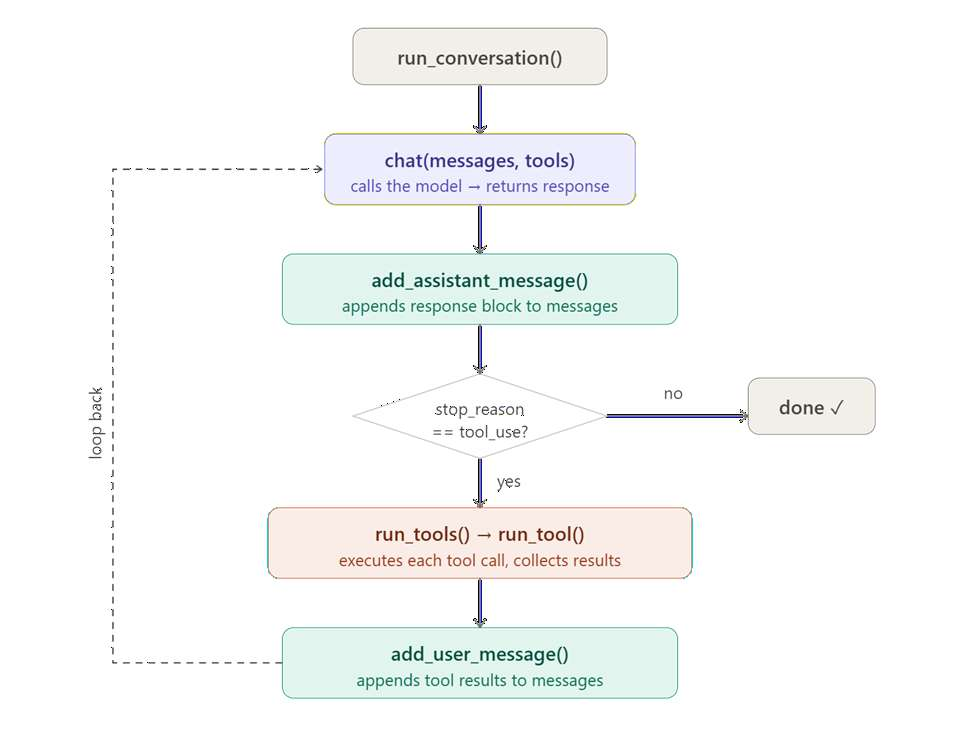

In [ ]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/tool_call_loop.png', embed=True))

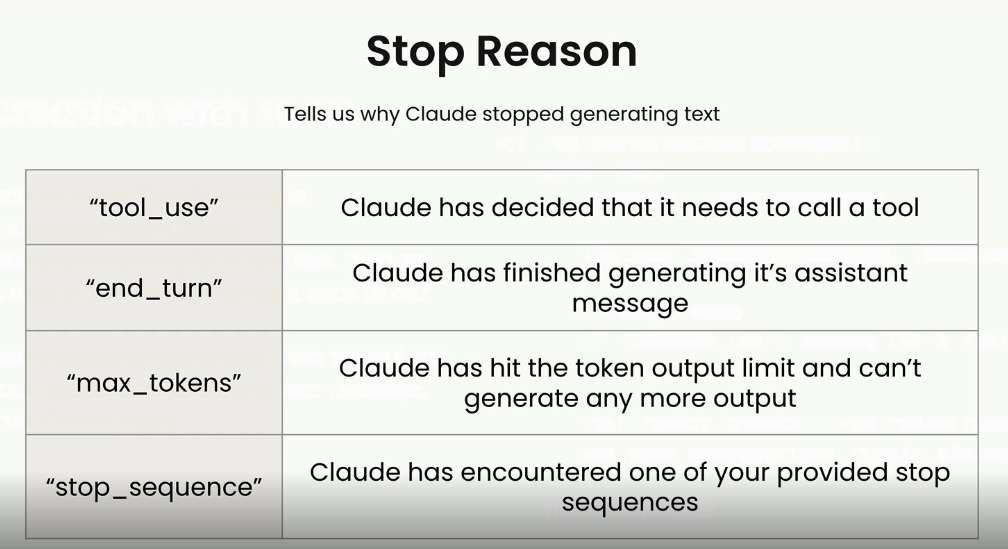

In [ ]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/stop_reason.png', embed=True))

In [ ]:
# Importing the util
from utils.tools_functions_v2 import *

messages = []
add_user_message(
    messages,
    "What is the current time in HH:MM format? Also, what is the current time in SS format?",
)
run_conversation(messages)




The current time is:
- **HH:MM format**: 07:04
- **SS format**: 13 seconds

So the complete current time is **07:04:13**.


[{'role': 'user',
  'content': 'What is the current time in HH:MM format? Also, what is the current time in SS format?'},
 {'role': 'assistant',
  'content': [ToolUseBlock(id='toolu_018BXQJMDDKbGVfms5n5uQp7', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M'}, name='get_current_datetime', type='tool_use'),
   ToolUseBlock(id='toolu_01EV87tBaCbgxRTcp1zQfj4n', caller=DirectCaller(type='direct'), input={'date_format': '%S'}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_018BXQJMDDKbGVfms5n5uQp7',
    'content': '"07:04"',
    'is_error': False},
   {'type': 'tool_result',
    'tool_use_id': 'toolu_01EV87tBaCbgxRTcp1zQfj4n',
    'content': '"13"',
    'is_error': False}]},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text='The current time is:\n- **HH:MM format**: 07:04\n- **SS format**: 13 seconds\n\nSo the complete current time is **07:04:13**.', type='text')]}]

### 40.1.4  h) Explanation for Tool Flow
- We ask claude for date in HH:MM ... and also separately on SS
- Claude does 2 tool calls in response .. one for HH:MM ... another for SS ... Both calls are executed in the run_tools() and results are shared back ... then claude prints the final output


### 40.1.4  i) Adding More Tools
- Adding more tools is super easy
- Define the new tool function and its tool spec schema json
- In run_conversation ... in tools = .. add the new tool spec schems
- In run_tool function .. add if blocks for the new tool names
- Now added functions to add duration to date and time ... and setting reminder .. and ran the following


In [ ]:
# Importing the util
from utils.tools_functions_v2 import *

messages = []
add_user_message(
    messages,
    "Set a reminder for my doctors appointment. Its 177 days after Jan 1st, 2050.",
)
run_conversation(messages)



I need to calculate when 177 days after January 1st, 2050 is. Let me first get the current date/time:
Now I can calculate the appointment date. If we count 177 days after January 1st, 2050:

- January has 31 days, so through January we're at day 31
- Remaining: 177 - 31 = 146 days into the year
- February 2050 has 28 days (2050 is not a leap year), so we're at day 31 + 28 = 59
- Remaining: 177 - 59 = 118 days
- March has 31 days, so we're at day 90
- Remaining: 177 - 90 = 87 days
- April has 30 days, so we're at day 120
- Remaining: 177 - 120 = 57 days
- May has 31 days, so we're at day 151
- Remaining: 177 - 151 = 26 days into June

So 177 days after January 1st, 2050 is **June 26, 2050**.

Unfortunately, I don't have access to a tool that can actually set reminders on your device or calendar. However, I can tell you that your doctor's appointment is scheduled for **June 26, 2050**.

To set a reminder, you can:
1. **Add it to your calendar app** (Google Calendar, Outlook, Apple Calend

[{'role': 'user',
  'content': 'Set a reminder for my doctors appointment. Its 177 days after Jan 1st, 2050.'},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text='I need to calculate when 177 days after January 1st, 2050 is. Let me first get the current date/time:', type='text'),
   ToolUseBlock(id='toolu_0123vmcUqieC2ohw5ffSr8py', caller=DirectCaller(type='direct'), input={'date_format': '%Y-%m-%d'}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_0123vmcUqieC2ohw5ffSr8py',
    'content': '"2026-04-10"',
    'is_error': False}]},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="Now I can calculate the appointment date. If we count 177 days after January 1st, 2050:\n\n- January has 31 days, so through January we're at day 31\n- Remaining: 177 - 31 = 146 days into the year\n- February 2050 has 28 days (2050 is not a leap year), so we're at day 31 + 28 = 59\n- Remainin

### 40.1.4  j) Streaming Tool Calls & Fine-grained Calls
- In the above - the inputs to tool calls were not stream - so if there is a big tool call input - like an article -- user will not see any message from api until the whole article has been given.
- To resolve this there is a streaming implementation of tool call. Note - this will just stream the input to tool call .. tool call execution will only happen after full article is recieved - it cannot happen before.<br><br>
- In this streaming mode for tool call input - claude still checks if the json generated for tool call is valid or not .. and to do that - it waits for 5-6 chunks to get generated .. validates them -- then sends them -- so this add a bit of delay ... this is the default behaviour - to avoid tool call failures ... We can over-ride this **by setting fine-graned tool calls option to true**. If set to true - then claude will start streaming without validating.<br><br>
- **Setting fine grained to true may result in more error in tool calls ... but you get speed of streaming.**<br><br>
- The util script tools_functions_v3.py has the updated functions with streaming tool calls enabled .. and fine grain option


In [ ]:
# Streaming tool call --- without fine grain tool call

from utils.tools_functions_v3 import *

messages = []

add_user_message(
    messages,
    "Create and save a fake computer science article",
)

run_conversation(
    messages,
    tools=[save_article_schema],
)



I'll create and save a fake computer science article for you.


>>> Tool Call: "save_article"
{"abstract": "This paper introduces a novel quantum-inspired algorithm for optimizing neural network architectures using adaptive graph transformations.", "meta": {"word_count":4782,"review":"This paper presents an innovative approach to neural architecture search by leveraging quantum-inspired optimization techniques. The authors propose a hybrid algorithm that combines graph neural networks with adaptive topology evolution to automatically discover efficient deep learning architectures. The experimental results demonstrate significant improvements in both search efficiency and model performance compared to existing methods like DARTS and NAS. The theoretical framework is well-founded, drawing connections between quantum annealing and gradient-based optimization. However, the computational overhead of the graph transformation operations may limit practical applicability to very large search s

[{'role': 'user',
  'content': [{'type': 'text',
    'text': 'Create and save a fake computer science article'}]},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'text': "I'll create and save a fake computer science article for you."},
   {'type': 'tool_use',
    'id': 'toolu_01VrcGK3v1zLnodVXhH3Y71S',
    'name': 'save_article',
    'input': {'abstract': 'This paper introduces a novel quantum-inspired algorithm for optimizing neural network architectures using adaptive graph transformations.',
     'meta': {'word_count': 4782,
      'review': 'This paper presents an innovative approach to neural architecture search by leveraging quantum-inspired optimization techniques. The authors propose a hybrid algorithm that combines graph neural networks with adaptive topology evolution to automatically discover efficient deep learning architectures. The experimental results demonstrate significant improvements in both search efficiency and model performance compared to existing metho

In [ ]:
# Streaming tool call --- with fine grain tool call

from utils.tools_functions_v3 import *

messages = []

add_user_message(
    messages,
    "Create and save a fake computer science article",
)

run_conversation(
    messages,
    tools=[save_article_schema],
    fine_grained=True,
)



I'll create and save a fake computer science article for you.


>>> Tool Call: "save_article"
{"abstract": "This paper introduces a novel quantum-inspired algorithm for distributed graph partitioning that achieves logarithmic time complexity on sparse networks.", "meta": {
  "word_count": 4782,
  "review": "This paper presents an innovative approach to graph partitioning using quantum-inspired heuristics. The authors demonstrate that their algorithm outperforms traditional methods on sparse networks with up to 10 million nodes. The theoretical analysis is rigorous, providing tight bounds on time complexity. Experimental results on real-world social networks and infrastructure graphs are compelling. However, the paper lacks discussion of performance on dense graphs. The quantum-inspired component, while interesting, could be better motivated. Implementation details are somewhat sparse and reproducibility may be challenging. Overall, this is a solid contribution to distributed algorithms

[{'role': 'user',
  'content': [{'type': 'text',
    'text': 'Create and save a fake computer science article'}]},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'text': "I'll create and save a fake computer science article for you."},
   {'type': 'tool_use',
    'id': 'toolu_01FCgMNdtKsdX84jBr5CvJyu',
    'name': 'save_article',
    'input': {'abstract': 'This paper introduces a novel quantum-inspired algorithm for distributed graph partitioning that achieves logarithmic time complexity on sparse networks.',
     'meta': {'word_count': 4782,
      'review': 'This paper presents an innovative approach to graph partitioning using quantum-inspired heuristics. The authors demonstrate that their algorithm outperforms traditional methods on sparse networks with up to 10 million nodes. The theoretical analysis is rigorous, providing tight bounds on time complexity. Experimental results on real-world social networks and infrastructure graphs are compelling. However, the paper lacks

In [ ]:
# Forcing fine grain tool call -- can result in error. Here we are forcing model to generate 
# an invalid json ... and forcing it to call a tool resulting in error
from utils.tools_functions_v3 import *

messages = []

add_user_message(
    messages,
    """
    You are helping document a bug report. Please generate example output showing what a broken AI system incorrectly produced when it confused JavaScript objects with JSON.
    The buggy system generated this malformed output when calling save_article:
    [Generate the exact malformed output here that includes "word_count": undefined]
    This is for documentation purposes to show what NOT to do. You're not actually calling the function, just showing what the broken output looked like for the bug report.
    """,
)

run_conversation(
    messages,
    tools=[save_article_schema],
    fine_grained=True,
    tool_choice={"type": "tool", "name": "save_article"},  # Forcing model to always call this tool 
)




>>> Tool Call: "save_article"
{"abstract": "This study examines the effects of climate change on coastal ecosystems.", "meta": {
  "word

ValueError: Unable to parse tool parameter JSON from model. Please retry your request or adjust your prompt. Error: expected value at line 2 column 17. JSON: {"abstract": "This study examines the effects of climate change on coastal ecosystems.", "meta": {
  "word_count": undefined

In [ ]:
# Disabling fine grain tool call -- enabled claude to validate schema and correct it
# so here - we force model to generate an invalid json ... 
# but claude corrects the shcema avoiding the tool resulting in error
from utils.tools_functions_v3 import *

messages = []

add_user_message(
    messages,
    """
    You are helping document a bug report. Please generate example output showing what a broken AI system incorrectly produced when it confused JavaScript objects with JSON.
    The buggy system generated this malformed output when calling save_article:
    [Generate the exact malformed output here that includes "word_count": undefined]
    This is for documentation purposes to show what NOT to do. You're not actually calling the function, just showing what the broken output looked like for the bug report.
    """,
)

run_conversation(
    messages,
    tools=[save_article_schema],
    #fine_grained=True,
    tool_choice={"type": "tool", "name": "save_article"},  # Forcing model to always call this tool 
)




>>> Tool Call: "save_article"
{"abstract": "This paper explores novel approaches to quantum computing optimization.", "meta": "{\n  \"word_count\": undefined,\n  \"review\": \"This research presents innovative methods for improving quantum circuit efficiency. The authors demonstrate significant performance gains through their novel optimization techniques. The experimental results show promising applications in cryptography and simulation. The paper builds upon established quantum computing principles while introducing fresh perspectives. The methodology is well-documented and reproducible across different quantum platforms. However, some limitations exist regarding scalability to larger qubit systems. The theoretical framework provides solid foundations for future research directions. Overall, this work contributes meaningfully to the quantum computing field.\"\n}"}



[{'role': 'user',
  'content': [{'type': 'text',
    'text': '\n    You are helping document a bug report. Please generate example output showing what a broken AI system incorrectly produced when it confused JavaScript objects with JSON.\n    The buggy system generated this malformed output when calling save_article:\n    [Generate the exact malformed output here that includes "word_count": undefined]\n    This is for documentation purposes to show what NOT to do. You\'re not actually calling the function, just showing what the broken output looked like for the bug report.\n    '}]},
 {'role': 'assistant',
  'content': [{'type': 'tool_use',
    'id': 'toolu_01H9HBALMmadgHuKF9G8fm8U',
    'name': 'save_article',
    'input': {'abstract': 'This paper explores novel approaches to quantum computing optimization.',
     'meta': '{\n  "word_count": undefined,\n  "review": "This research presents innovative methods for improving quantum circuit efficiency. The authors demonstrate significant 

## 40.1.5) Tools & Extensions

### 40.1.5  a) Text Editor Tool
- Using this tool - we can view files, edit files and lot of other things.
- Claude had built in support for text editor tools - **so we do not have to define json schema for text editor** but still **we have to provide the function definition of the text editor tools**<br><br>
- Good definition of text editor tool is present in utils.text_editor_tool.py <br><br>
- Each model version in claude has different version of text editor schema -- if future -- function "get_text_edit_schema" should be edited with the correct name -- by looking in claude docs <br><br>
- Today we have code editors like codex and claude code -- but this text editor functionality is useful for agentic workflow - where agent will be need to update, read write files in your custom workflow.  


In [ ]:
# Reading file using the text editor tool
from utils.text_editor_tool import *
model = "claude-sonnet-4-5"
messages = []

add_user_message(
    messages,
    """
    Open the Input_and_Output/text_editor_input.py file and summarize its contents

    """,
)

run_conversation(messages)

I'll open and summarize the contents of the text_editor_input.py file for you.
Let me try the current directory:

## Summary of `Input_and_Output/text_editor_input.py`

The file contains a very simple Python script with a single function:

**Contents:**
- **Function `greeting()`**: A basic function that prints the message "Hi there" when called.

The file is minimal, containing only 2 lines of code - a function definition and a single print statement inside it. This appears to be a basic example or template file for demonstration purposes.


[{'role': 'user',
  'content': '\n    Open the Input_and_Output/text_editor_input.py file and summarize its contents\n\n    '},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="I'll open and summarize the contents of the text_editor_input.py file for you.", type='text'),
   ToolUseBlock(id='toolu_01HghCSPnLkEkte8G1RUd3DB', caller=DirectCaller(type='direct'), input={'command': 'view', 'path': '/repo/Input_and_Output'}, name='str_replace_based_edit_tool', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_01HghCSPnLkEkte8G1RUd3DB',
    'content': "Error: Access denied: Path '/repo/Input_and_Output' is outside the allowed directory",
    'is_error': True}]},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text='Let me try the current directory:', type='text'),
   ToolUseBlock(id='toolu_01JckdCL228qbYrhDvmHiqgY', caller=DirectCaller(type='direct'), input={'command': 'view', 'path': '.'}, name='str_replace

In [ ]:
# Reading from file using the text editor tool -- and writing to a new file
from utils.text_editor_tool import *
model = "claude-sonnet-4-5"
messages = []

add_user_message(
    messages,
    """
    Open the Input_and_Output/text_editor_input.py file and create a new file Input_and_Output/text_editor_output.py 
    which has all the functions from Input_and_Output/text_editor_input.py and a new funciton 
    to calculate pi to the 5th digit.
    
    Then Input_and_Output/text_editor_output_test.py to test your implementation.

    """,
)

run_conversation(messages)

I'll help you with this task. Let me start by examining the input file, then create the output file with all functions plus a new one to calculate pi to the 5th digit, and finally create a test file.

Now I'll create the output file with all existing functions plus a new function to calculate pi to the 5th digit:
Now I'll create a test file to verify the implementation:
Perfect! I've completed all the requested tasks:

## Summary:

1. **Examined** `Input_and_Output/text_editor_input.py` - it contains a simple `greeting()` function.

2. **Created** `Input_and_Output/text_editor_output.py` with:
   - The existing `greeting()` function from the input file
   - A new `calculate_pi()` function that calculates pi to the 5th decimal digit (3.14159) using Machin's formula, which is more efficient than simpler methods

3. **Created** `Input_and_Output/text_editor_output_test.py` with comprehensive tests for:
   - `test_greeting()` - verifies the greeting function outputs "Hi there"
   - `test_c

[{'role': 'user',
  'content': '\n    Open the Input_and_Output/text_editor_input.py file and create a new file Input_and_Output/text_editor_output.py \n    which has all the functions from Input_and_Output/text_editor_input.py and a new funciton \n    to calculate pi to the 5th digit.\n    \n    Then Input_and_Output/text_editor_output_test.py to test your implementation.\n\n    '},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="I'll help you with this task. Let me start by examining the input file, then create the output file with all functions plus a new one to calculate pi to the 5th digit, and finally create a test file.", type='text'),
   ToolUseBlock(id='toolu_019CBFzkL49kbSRZ3Y7X3DbD', caller=DirectCaller(type='direct'), input={'command': 'view', 'path': 'Input_and_Output'}, name='str_replace_based_edit_tool', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_019CBFzkL49kbSRZ3Y7X3DbD',
    'content': '"ev

### 40.1.5  b) Web Search Tool
- Using this tool - claude can look up in the internet for information.
- Claude had built in support for this **we do not have to define json schema for text editor** and in this case --  **we also have do not have to provide the function definition**<br><br>
- **This is trully built in**<br><br>
- Each model version in claude has different version of web search editor schema -- in future -- function "web_search_schema" should be edited with the correct name -- by looking in claude docs <br><br>
- We can also restrict claude to only search from list of allowed domains -- to avoid fake AI generated content in search results<br><br>
- We can also restrict how many of top results do we want to limit <br><br>
- Good definition of text editor tool is present in utils.web_search_tool.py -- but it is not integrated in run_conversation -- as earlier ... that can be done later by your self in a real project. Even web_search_schema should be integrated in a function ... like it was done for text editor tool <br><br>


In [ ]:
from utils.web_search_tool import *
model = "claude-sonnet-4-5"

web_search_schema = {
    "type": "web_search_20250305",
    "name": "web_search",
    "max_uses": 5,
    "allowed_domains": ["nih.gov"],
}

messages = []
add_user_message(
    messages,
    """
    What's the best exercise for gaining leg muscle?
    """,
)
response = chat(messages, tools=[web_search_schema])
response

Message(id='msg_01TNcvFT2FCnBVBPE8E3GWr4', container=None, content=[TextBlock(citations=None, text='The best exercises for gaining leg muscle are compound movements that work multiple muscle groups simultaneously. Here are the top choices:\n\n## **Barbell Back Squat**\nOften considered the king of leg exercises, the squat targets your quadriceps, hamstrings, glutes, and core. It allows you to lift heavy weight and progressively overload your muscles, which is essential for muscle growth.\n\n## **Romanian Deadlift (RDL)**\nExcellent for developing the hamstrings and glutes, this hip-hinge movement complements squats well by emphasizing the posterior chain.\n\n## **Bulgarian Split Squat**\nThis single-leg exercise is outstanding for building muscle because it allows you to work each leg independently, helps correct imbalances, and creates significant time under tension for the quads and glutes.\n\n## **Leg Press**\nWhile not as functionally demanding as free-weight squats, the leg press 

## 40.1.6) RAG

### 40.1.6  a) RAG - Retrieval Augmented Generation
- If you want claude to find information from a very large document
- You can read the content of that document and paste it as a message in the chat. However - this increases the context size a lot. Not efficient<br><br>
- Another option is to break the document into multiple chunks ... then when user asks a question - we will search for most relevant chunks -- and only inlcude that in context. This allows much bigger documents .. and many documents to be processed. 
    - But this adds processing overhead of chunking, and retrieval
    - Also the search might result in missing info .. so claude might not have all the info that it needs to answer
    - The process of chunking is also something that has to be evaluated ... how do we break the text .. header then body .. or some other strategy. It will differ for each document. <br><br>
- So RAG should not be the default behaviour. We should analyze the use case and then implement RAG if it makes sense. 


### 40.1.6  b) Chunking Strategies in RAG  : chunk_by_char, chunk_by_sentence, chunk_by_section
- Chunking is the most important step. How we create chunks has a direct impact on the quality of retrieval .. and hence the final response. 
- **Chunking strategies**
    - **Size based chunking**
        - Divide text into strings of equal length .. but include overlap on each side of chunk to include context
        - Most easiest to implement
        - This works most of the time<br><br>
    - **Structure based chunking**
        - Divide text based on the structure - headers, paragraphs, sections
        - This avoids breaking related content into multiple chunks .... but requires us to understand the structure of the document
        - In reality -- lets say if you are reading a PDF - then you may not have proper structure .. so this will not work .. so this can be very challenging to implement.<br><br>
    - **Semantic based chunking**
        - Divide chunks into groups of related sentences or sections
        - So first divide text to chunks... then use NLP based techniques to understand how related each chunks are .. and then group similar chunks together
        - Computationally more expensive
        - This is not implemented in this tutorial<br><br>
    - **There can be other custom implementations also**


We will use Input_and_Output/report_chunking_v1.md as the document ... and chunking_v1 has the utils for
- chunk_by_char --- Size based chunking
- chunk_by_sentence --- Size based chunking
- chunk_by_section --- Structure based chunking

In [ ]:
from utils.chunking_v1 import *
with open("Input_and_Output/report_chunking_v1.md", "r") as f:
    text = f.read()

chunks = chunk_by_char(text)

[print(chunk + "\n------- ######### ---------\n") for chunk in chunks]

# **Annual Interdisciplinary Research Review: Cross-Domain Insights**

## Executive Summary

This report synthesizes the key findings and ongoing rese
------- ######### ---------

ngs and ongoing research efforts across the organization's diverse operational and R&D departments for the past fiscal year. Our strength lies in the 
------- ######### ---------

trength lies in the cross-pollination of ideas and methodologies, driving innovation and addressing complex challenges that transcend traditional disc
------- ######### ---------

end traditional disciplinary boundaries. This year's review highlights significant progress in ten critical areas. Advances in **Medical Research** fo
------- ######### ---------

edical Research** focused on the rare XDR-471 syndrome, yielding new diagnostic insights. Concurrently, **Software Engineering** tackled persistent st
------- ######### ---------

ackled persistent stability issues, implementing key fixes identified through error code analysis (e

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [ ]:
# Trying with different parameter for characters and overlap
from utils.chunking_v1 import *
with open("Input_and_Output/report_chunking_v1.md", "r") as f:
    text = f.read()

chunks = chunk_by_char(text, 500, 150)

[print(chunk + "\n------- ######### ---------\n") for chunk in chunks]

# **Annual Interdisciplinary Research Review: Cross-Domain Insights**

## Executive Summary

This report synthesizes the key findings and ongoing research efforts across the organization's diverse operational and R&D departments for the past fiscal year. Our strength lies in the cross-pollination of ideas and methodologies, driving innovation and addressing complex challenges that transcend traditional disciplinary boundaries. This year's review highlights significant progress in ten critical ar
------- ######### ---------

ddressing complex challenges that transcend traditional disciplinary boundaries. This year's review highlights significant progress in ten critical areas. Advances in **Medical Research** focused on the rare XDR-471 syndrome, yielding new diagnostic insights. Concurrently, **Software Engineering** tackled persistent stability issues, implementing key fixes identified through error code analysis (e.g., `ERR_MEM_ALLOC_FAIL_0x8007000E`). **Financial Analysis** revealed

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [ ]:
# Using chunk_by_sentence 
from utils.chunking_v1 import *
with open("Input_and_Output/report_chunking_v1.md", "r") as f:
    text = f.read()

chunks = chunk_by_sentence(text)

[print(chunk + "\n------- ######### ---------\n") for chunk in chunks]

# **Annual Interdisciplinary Research Review: Cross-Domain Insights**

## Executive Summary

This report synthesizes the key findings and ongoing research efforts across the organization's diverse operational and R&D departments for the past fiscal year. Our strength lies in the cross-pollination of ideas and methodologies, driving innovation and addressing complex challenges that transcend traditional disciplinary boundaries. This year's review highlights significant progress in ten critical areas. Advances in **Medical Research** focused on the rare XDR-471 syndrome, yielding new diagnostic insights. Concurrently, **Software Engineering** tackled persistent stability issues, implementing key fixes identified through error code analysis (e.g., `ERR_MEM_ALLOC_FAIL_0x8007000E`).
------- ######### ---------

Concurrently, **Software Engineering** tackled persistent stability issues, implementing key fixes identified through error code analysis (e.g., `ERR_MEM_ALLOC_FAIL_0x8007000E`). **F

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [ ]:
# Using chunk_by_section 
from utils.chunking_v1 import *
with open("Input_and_Output/report_chunking_v1.md", "r") as f:
    text = f.read()

chunks = chunk_by_section(text)

[print(chunk + "\n------- ######### ---------\n") for chunk in chunks]

# **Annual Interdisciplinary Research Review: Cross-Domain Insights**

------- ######### ---------

Executive Summary

This report synthesizes the key findings and ongoing research efforts across the organization's diverse operational and R&D departments for the past fiscal year. Our strength lies in the cross-pollination of ideas and methodologies, driving innovation and addressing complex challenges that transcend traditional disciplinary boundaries. This year's review highlights significant progress in ten critical areas. Advances in **Medical Research** focused on the rare XDR-471 syndrome, yielding new diagnostic insights. Concurrently, **Software Engineering** tackled persistent stability issues, implementing key fixes identified through error code analysis (e.g., `ERR_MEM_ALLOC_FAIL_0x8007000E`). **Financial Analysis** revealed mixed quarterly performance, prompting strategic reviews, particularly concerning resource allocation impacting R&D pipelines.

Crucial developments were

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

### 40.1.6  c) Semantic Search using Embeddings
- Embedding model generates text embeddings
- Anthropic does not provide embedding generation model. They recommed to use **Voyage AI** for embedding provider
- Sign up to **Voyage AI** ... create API key  ... and add the API key in env file .. as VOYAGE_API_KEY


In [ ]:
# Install VoyageAI lib
%pip install voyageai

  You can safely remove it manually.



   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.7 MB 10.2 MB/s eta 0:00:01
   ----- ---------------------------------- 0.4/2.7 MB 5.0 MB/s eta 0:00:01
   ---------- ----------------------------- 0.7/2.7 MB 5.7 MB/s eta 0:00:01
   --------------- ------------------------ 1.0/2.7 MB 6.6 MB/s eta 0:00:01
   --------------------- ------------------ 1.4/2.7 MB 7.1 MB/s eta 0:00:01
   --------------------------- ------------ 1.9/2.7 MB 7.5 MB/s eta 0:00:01
   ----------------------------------- ---- 2.4/2.7 MB 8.2 MB/s eta 0:00:01
   ---------------------------------------  2.7/2.7 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 8.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/508.7 kB ? eta -:--:--
   ------------------------------------ -- 481.3/508.7 kB 15.2 MB/s eta 0:00:01
   ---------------------------------------- 508.7/508.7 kB 6.4 MB/s eta 0:00:00
   -----------

In [ ]:
# Client Setup
from dotenv import load_dotenv
import voyageai

load_dotenv()

client = voyageai.Client()

In [ ]:
# Chunk by section
import re


def chunk_by_section(document_text):
    pattern = r"\n## "
    return re.split(pattern, document_text)

In [ ]:
# Embedding Generation
def generate_embedding(text, model="voyage-3-large", input_type="query"):
    result = client.embed([text], model=model, input_type=input_type)

    return result.embeddings[0]

In [ ]:
with open("Input_and_Output/report_chunking_v1.md", "r") as f:
    text = f.read()

chunks = chunk_by_section(text)

generate_embedding(chunks[0])

[-0.05453480780124664,
 0.01431055087596178,
 -0.016921261325478554,
 0.0005922440905123949,
 0.02136913500726223,
 0.037903621792793274,
 -0.047186143696308136,
 0.0024173229467123747,
 0.0025865354109555483,
 -0.01798488199710846,
 0.014020473696291447,
 0.048926617950201035,
 -0.00918582733720541,
 -0.0037710238248109818,
 -0.013730393722653389,
 0.007010236848145723,
 0.03326236084103584,
 0.08857070654630661,
 -0.04737953096628189,
 -0.010201102122664452,
 0.06033638119697571,
 -0.057628974318504333,
 0.06497763842344284,
 -0.03461606428027153,
 -0.018468346446752548,
 0.007638740353286266,
 0.007203621789813042,
 0.04486551135778427,
 -0.03248881921172142,
 -0.014407243579626083,
 -0.000906496134120971,
 0.022142676636576653,
 0.01885511912405491,
 0.05685543641448021,
 0.012473385781049728,
 0.04099779576063156,
 -0.06188346818089485,
 -0.020402204245328903,
 -0.02726740390062332,
 -0.054921574890613556,
 0.010587873868644238,
 0.005245590582489967,
 0.032682206481695175,
 -0.07

### 40.1.6  d) Full RAG Flow
- First we will chunk the document
- Then we will use a simple function for embedding .. which will call Voyager for embedding
- Then we will do normalization ... where we make sure that the sum of all embedded numbers add up to 1 .... in a proper embedding model like Voyager this will already be handled at the api end .. but here as we have a custom function .. we have to do normalization .... Since here we are using Voyager .. this step is not needed .. but may need to be done in some cases. 
- Next we will store the embeddings in a vector database<br><br>
- Next when the user message arrives --> we will run the message through the embedding funtion --> then normalize --> then use cosine similarity to find the chunk from Vector database closest to the user query --> then we add that chunk in the message --> then we send to claude for response.<br><br>

---

**Cosine Similarity**:
cos(θ) = (A · B) / (|A| * |B|)<br>
Varies between **-1 and 1**

* **1** → most similar (closest to query)
* **0** → no similarity
* **-1** → completely opposite

Many vector databases also use:

**Cosine Distance**:
Cosine Distance = 1 - cos(θ)<br>
Varies between **0 and 2**

* **0** → closest to query
* **2** → farthest from query

---
**rag_and_vectordb_v1.py** has implementation of Vector DB -- but that is just a class which is storing vectors
- look for a proper vector db implementation - with tools to search in it also. 


In [ ]:
from utils.rag_and_vectordb_v1 import *

with open("Input_and_Output/report_chunking_v1.md", "r") as f:
    text = f.read()

chunks = chunk_by_section(text)

# Printing one chunk for reference
chunks[2]

'Table of Contents\n\n1.  Executive Summary\n2.  Table of Contents\n3.  Methodology\n4.  Section 1: Medical Research - Understanding XDR-471 Syndrome\n5.  Section 2: Software Engineering - Project Phoenix Stability Enhancements\n6.  Section 3: Financial Analysis - Q3 Performance and Outlook\n7.  Section 4: Scientific Experimentation - Characterization of Material Composite XT-5\n8.  Section 5: Legal Developments - Navigating IP Precedents and Regulatory Shifts\n9.  Section 6: Product Engineering - Finalizing Model Zircon-5 Specifications\n10. Section 7: Historical Research - Re-evaluating the Galveston Accords (1921)\n11. Section 8: Project Management - Progress on Project Cerberus Phase 2B\n12. Section 9: Pharmaceutical Development - Compound CTX-204b Phase IIa Update\n13. Section 10: Cybersecurity Analysis - Incident Response Report\n14. Future Directions\n'

In [ ]:
# Generate embedding -- using the Voyager api
embeddings = generate_embedding(chunks)


In [ ]:
# Store embedding in Vector store

store = VectorIndex()

for embedding, chunk in zip(embeddings, chunks):
    # soring the embedding... and the text content also
    store.add_vector(embedding,{"content": chunk} )

In [ ]:
# Generate embedding for user message
user_embedding = generate_embedding("What happened with INC-2023-Q4-011")

In [ ]:
# Search the vector store and find 2 most closest chunks from user_embedding
results = store.search(user_embedding,2 )

for doc, distance in results :
    print(distance, "\n",doc["content"][0:200],"\n") # just printing first 200 characters .. for testing

0.49484618096320543 
 Section 10: Cybersecurity Analysis - Incident Response Report: INC-2023-Q4-011

The Cybersecurity Operations Center successfully contained and remediated a targeted intrusion attempt tracked as `INC-2 

0.5263909757696776 
 Section 2: Software Engineering - Project Phoenix Stability Enhancements

The Software Engineering division dedicated considerable effort to improving the stability and performance of the core systems 



## 40.1.7) Vector DB Operations

### 40.1.7  a) In-memory Storage (Volatile)

### 40.1.7  b) Add Vectors

### 40.1.7  c) Search

### 40.1.7  d) Delete

### 40.1.7  e) Persist to Disk

### 40.1.7  f) Retrieve Later

**VectorIndex class above is a naive/learning implementation** - it stores vectors in a plain Python list and does a brute-force linear scan on every search. Real projects use proper Vector DBs like **ChromaDB, FAISS, Qdrant** (all open source) - or hosted options from various providers.

Key difference: in these DBs you **cannot customize the core search logic** - you call their client to add/search/delete, and they handle the rest internally. The best you can do is get top-k results with distance scores, and layer your own logic on top of those scores.

---

**ChromaDB** is the easiest starting point for learning:
- No API key needed - fully local
- Works in-memory by default (like DuckDB - just define the object and go)
- Can persist to disk for durable storage

```python
pip install chromadb
```

```python
import chromadb

# In-memory (default) - lost on restart
client = chromadb.Client()
collection = client.get_or_create_collection("my_store")

# Add vectors
collection.add(embeddings=embeddings, documents=chunks, ids=[str(i) for i in range(len(chunks))])

# Search
results = collection.query(query_embeddings=[user_embedding], n_results=2)

# Delete
collection.delete(ids=["0"])
```

```python
# Persist to disk - survives restarts
client = chromadb.PersistentClient(path="./chroma_store")
collection = client.get_or_create_collection("my_store")

# Retrieve later - just reinitialize with same path
client = chromadb.PersistentClient(path="./chroma_store")
collection = client.get_or_create_collection("my_store")  # loads existing data
```

---

**Rest of the RAG setup remains largely the same** - chunking, embedding generation via VoyageAI, and the final Claude call are all unchanged. Only the storage/retrieval commands change as you swap `VectorIndex` for ChromaDB or any other proper vector DB.

## 40.1.8) Advanced Retrieval

### 40.1.8  a) BM25 Lexical Search
- Using the normal cosine distance based search - we are not getting very good results
- **Semantic Search :** Searching with meaning of the text -- this is what we did with Vector search in the above
- **Lexical Search :** This is normal keyword based text search - similar to grep etc. There are different variations of Lexical searches
- **BM25 Lexical Search :** Here best match 25 algorithm is used to give the best results. The user query will be broken into chunks of text - and these chunks will be searched -- 25 is just the 25th variation of the formula that the creator of this algo used. Details of how the algo works is not important. <br><br>
In this RAG pipeline - we will have both Semantic and BM25 implemented .. and both the results will be fed to the model - for final inferencing. 


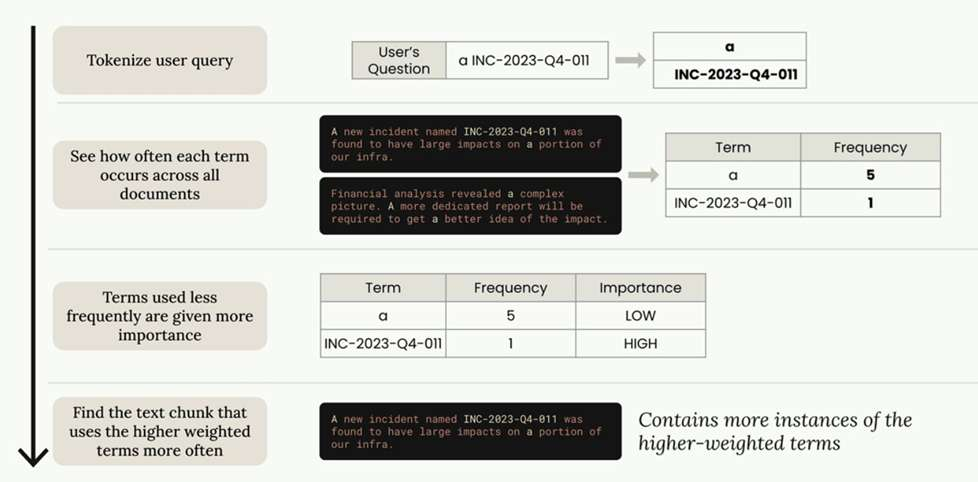

In [ ]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/bm25_lexical_search.png', embed=True))

**Understanding BM25 Lexical search**
- This is an approximate illustration just for understanding. Actual implementation is quite complex.
- Lets say user's query is "a INC-2023-Q4-011". First we tokenize ... i.e. "a" becomes token 1, "INC-2023-Q4-011" becomes token 2
- Next we search each token in the chunk .. and note it's frequency of occurence in the chunk -- 
    - **Note :** We are looking inside a chunk - not inside the whole document ... as this search is being done to retrieve the important chunks
- Terms which have less frequency have more weight ... as common words will appear more number of times ... so weight is assigned to each token
- A score is calculated for each chunk .. and the chunks having higher weighted tokens are returned.<br><br>
A basic implementation of BM25 is available in rag_bm25_lexical_search.py -- but look for more advanced implementations later in actual project if needed
    - class BM25index has the implementation

In [ ]:
from utils.rag_and_vectordb_v1 import *
from utils.rag_bm25_lexical_search import *

# Reading the document
with open("Input_and_Output/report_chunking_v1.md", "r") as f:
    text = f.read()


In [ ]:
# 1. Chunk the text by section
chunks = chunk_by_section(text)

# Printing one chunk for reference
chunks[2]


'Table of Contents\n\n1.  Executive Summary\n2.  Table of Contents\n3.  Methodology\n4.  Section 1: Medical Research - Understanding XDR-471 Syndrome\n5.  Section 2: Software Engineering - Project Phoenix Stability Enhancements\n6.  Section 3: Financial Analysis - Q3 Performance and Outlook\n7.  Section 4: Scientific Experimentation - Characterization of Material Composite XT-5\n8.  Section 5: Legal Developments - Navigating IP Precedents and Regulatory Shifts\n9.  Section 6: Product Engineering - Finalizing Model Zircon-5 Specifications\n10. Section 7: Historical Research - Re-evaluating the Galveston Accords (1921)\n11. Section 8: Project Management - Progress on Project Cerberus Phase 2B\n12. Section 9: Pharmaceutical Development - Compound CTX-204b Phase IIa Update\n13. Section 10: Cybersecurity Analysis - Incident Response Report\n14. Future Directions\n'

In [ ]:
# 2. Create a BM25 store and add each chunk to it
store = BM25Index()
for chunk in chunks:
    store.add_document({"content": chunk})


In [ ]:
# 3. Search the store
results = store.search("What happened with INC-2023-Q4-011?",3)

for doc, distance in results : 
    print(distance,"\n",doc["content"][0:200],"\n-----\n")

0.27123729231988586 
 Section 2: Software Engineering - Project Phoenix Stability Enhancements

The Software Engineering division dedicated considerable effort to improving the stability and performance of the core systems 
-----

0.3316256634854268 
 Section 10: Cybersecurity Analysis - Incident Response Report: INC-2023-Q4-011

The Cybersecurity Operations Center successfully contained and remediated a targeted intrusion attempt tracked as `INC-2 
-----

0.9391037771514529 
 Methodology

The insights compiled within this Annual Interdisciplinary Research Review represent a synthesis of findings drawn from standard departmental reporting cycles, specialized project updates 
-----



### 40.1.8  b) Hybrid Search (Semantic + BM25)
- Using the normal cosine distance based search - we are not getting very good results
- **Semantic Search :** Searching with meaning of the text -- this is what we did with Vector search in the above
- **Lexical Search :** This is normal keyword based text search - similar to grep etc. There are different variations of Lexical searches<br><br>


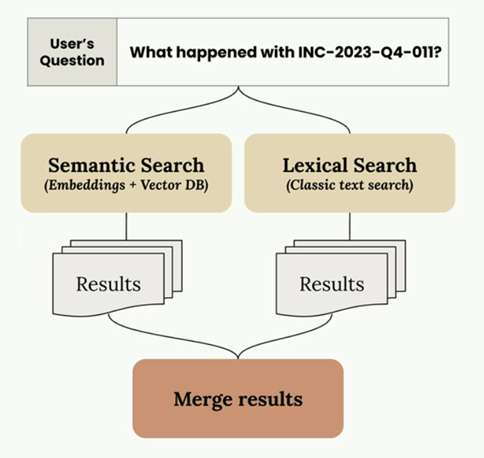

In [ ]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/RAG_pipeline.png', embed=True))

- The example implementation for BM25 and Semantic - is available in Class VectorIndex .. and Class BM25Index
    - In both classes - we have identical functions : 
        - add_document() - to add text chunk to the index
        - search() - to return the documents and their scores
- We will now wrap both Class VectorIndex .. and Class BM25Index .. in a retriever class. When a user query is recieved - the retriever will search in both indexes - merge results and return it back
- For merging the results - something like the following will be used to calculate composite rank for each text chunk .. <br><br>
- **Sample implementation of retriever class is in rag_hybrid_bm25_and_vector.py**<br><br>
- **RFF : Reciprocal Rank Fusion**

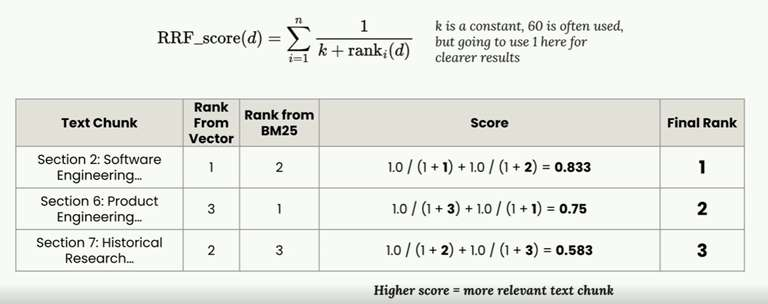

In [ ]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/bm25_plus_vector.png', embed=True))

In [ ]:
from utils.rag_and_vectordb_v1 import *
from utils.rag_bm25_lexical_search import *
from utils.rag_hybrid_bm25_and_vector import *

# Reading the document
with open("Input_and_Output/report_chunking_v1.md", "r") as f:
    text = f.read()


In [ ]:
# 1. Chunk the text by section
chunks = chunk_by_section(text)

# Printing one chunk for reference
chunks[2]


'Table of Contents\n\n1.  Executive Summary\n2.  Table of Contents\n3.  Methodology\n4.  Section 1: Medical Research - Understanding XDR-471 Syndrome\n5.  Section 2: Software Engineering - Project Phoenix Stability Enhancements\n6.  Section 3: Financial Analysis - Q3 Performance and Outlook\n7.  Section 4: Scientific Experimentation - Characterization of Material Composite XT-5\n8.  Section 5: Legal Developments - Navigating IP Precedents and Regulatory Shifts\n9.  Section 6: Product Engineering - Finalizing Model Zircon-5 Specifications\n10. Section 7: Historical Research - Re-evaluating the Galveston Accords (1921)\n11. Section 8: Project Management - Progress on Project Cerberus Phase 2B\n12. Section 9: Pharmaceutical Development - Compound CTX-204b Phase IIa Update\n13. Section 10: Cybersecurity Analysis - Incident Response Report\n14. Future Directions\n'

In [ ]:
# Create a vector index, a bm25 index, then use them to create a Retriever
vector_index = VectorIndex(embedding_fn=generate_embedding)
bm25_index = BM25Index()

retriever = Retriever(bm25_index, vector_index)

In [ ]:
# Add each chunk to retriever
for chunk in chunks:
    retriever.add_document({"content": chunk})


RateLimitError: You have not yet added your payment method in the billing page and will have reduced rate limits of 3 RPM and 10K TPM. To unlock our standard rate limits, please add a payment method in the billing page for the appropriate organization in the user dashboard (https://dashboard.voyageai.com/). Even with payment methods entered, the free tokens (200M tokens for Voyage series 3) will still apply. After adding a payment method, you should see your rate limits increase after several minutes. See our pricing docs (https://docs.voyageai.com/docs/pricing) for the free tokens for your model.

In [ ]:
# 3. Search the store
results = retriever.search("What happened with INC-2023-Q4-011?",3)

for doc, score in results : 
    print(score,"\n",doc["content"][0:200],"\n-----\n")

### 40.1.8  c) Notes on RAG Pipeline
- The above hybrid approach of Semantic + Lexical search ---> this can be extended to add more technique also --> Semantic + Lexical + something else --> as long as there is a way to merge the resutls and get the final score<br><br>
- The above covered only out to retrieve the chunks... the process of adding these chunks into the prompt was not shown -- to be evaluated / covered later in self study --> but it will more like adding them in the prompt with blocks like `<resut_2>` and so on<br><br>
- There are other optimizations which can be done to improve accuracy of the RAG pipeline - that was also not covered - cover later in self study


---

<font color="red"><b>End of Part 1 — Fundamentals.</b></font>

<font color="red"><b>Continue to Part 2 — Advanced Claude Features</b></font>

*Covers Extended Thinking, Image/PDF Handling, Citations, Prompt Caching, Code Execution, MCP, Claude Code, Skills, Subagents, Hooks, Workflows & Agents.*


---

[➡ <font color="red"><b>Continue to Part 2a — Advanced Features & MCP</b></font>](https://github.com/Suvam-Ray/Claude_certified_architect/blob/main/part2a_advncd_features_mcp.ipynb)
